Dual-use dataset shape: (22, 70)

=== ITEM ANALYSIS (Dual-Use) ===
                                                    ban_intensity  \
item                                                                
toxin                                                         0.0   
microbial/other biological agent                              0.0   
schedule 2 chemical                                           0.0   
schedule 3 chemical                                           0.0   
fissile material                                              0.0   
(category 2) arms and ammunition capable of use...            0.0   
category iv(aircrafts and aircrafts compenents)               0.0   
explosive                                                     0.0   
aircrafts (incl. their parts and engines)                     0.0   
dual-use goods and technologie                                0.0   
nuclear material                                              0.0   
space launch vehicle                

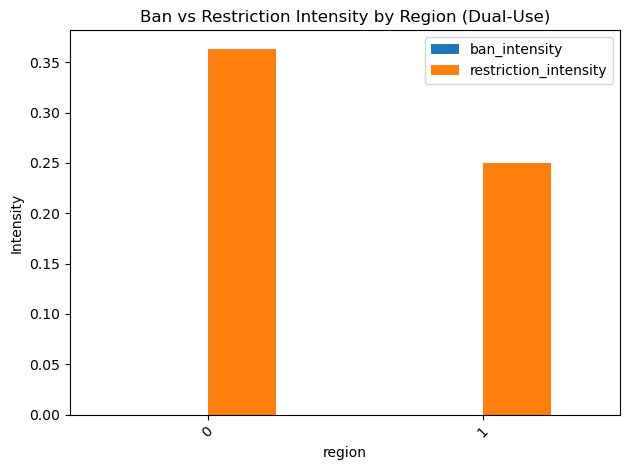


=== REGULATORY DENSITY (Top Items) ===
item
fissile material                                                                                            7
nuclear material                                                                                            3
aircrafts (incl. their parts and engines)                                                                   1
category iv(aircrafts and aircrafts compenents)                                                             1
dual-use goods and technologie                                                                              1
(category 2) arms and ammunition capable of use both for military and other purpose                         1
explosive                                                                                                   1
instruments for use on aircraft (incl. wireless apparatus and photographic or cinematographic apparatus)    1
laser                                                                      

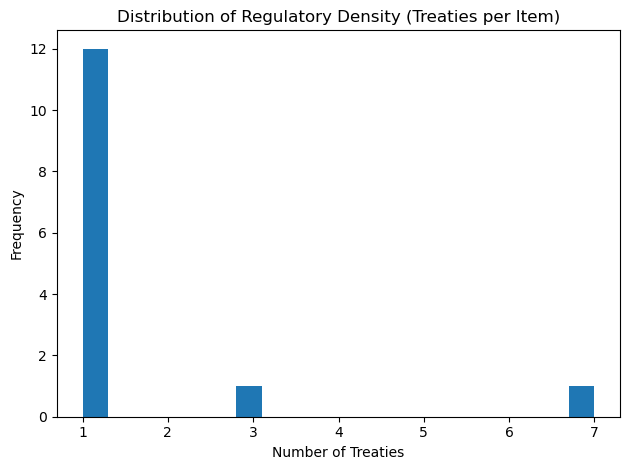


=== FRAGMENTATION (Regions per Item) ===
item
fissile material                                                                                            2
(category 2) arms and ammunition capable of use both for military and other purpose                         1
aircrafts (incl. their parts and engines)                                                                   1
category iv(aircrafts and aircrafts compenents)                                                             1
dual-use goods and technologie                                                                              1
explosive                                                                                                   1
instruments for use on aircraft (incl. wireless apparatus and photographic or cinematographic apparatus)    1
laser                                                                                                       1
microbial/other biological agent                                         

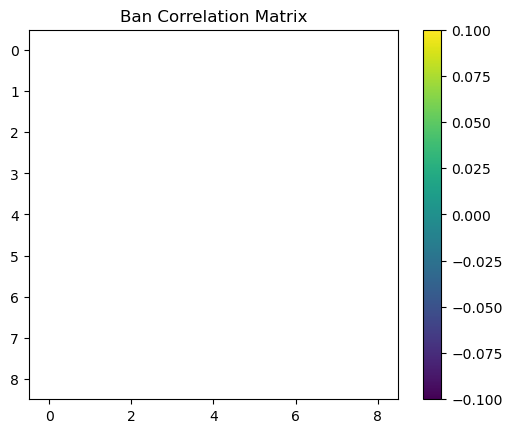


=== RESTRICTION vs RESTRICTION CORRELATION ===
                         restriction_development  testing_restriction  \
restriction_development                 1.000000             1.000000   
testing_restriction                     1.000000             1.000000   
restriction_production                  0.239046             0.239046   
restriction_acquisition                -0.149071            -0.149071   
restriction_possession                  0.670820             0.670820   
restriction_transfer                    0.216025             0.216025   
restriction_use                        -0.380058            -0.380058   
restriction_disposal                         NaN                  NaN   

                         restriction_production  restriction_acquisition  \
restriction_development                0.239046                -0.149071   
testing_restriction                    0.239046                -0.149071   
restriction_production                 1.000000                 0.

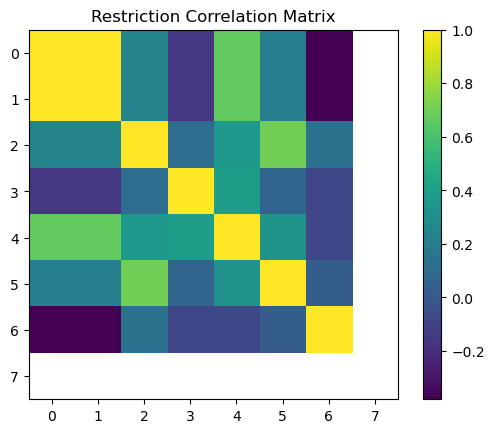


=== BAN vs RESTRICTION CORRELATION ===
                restriction_development testing_restriction  \
ban_development                     NaN                 NaN   
ban_testing                         NaN                 NaN   
ban_production                      NaN                 NaN   
ban_acquisition                     NaN                 NaN   
ban_possession                      NaN                 NaN   
ban_station                         NaN                 NaN   
ban_transfer                        NaN                 NaN   
ban_use                             NaN                 NaN   
ban_disposal                        NaN                 NaN   

                restriction_production restriction_acquisition  \
ban_development                    NaN                     NaN   
ban_testing                        NaN                     NaN   
ban_production                     NaN                     NaN   
ban_acquisition                    NaN                     NaN   

/usr/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. LOAD DATA
# ---------------------------
# weapons_df = pd.read_csv("database_with_dualuse_mapping.csv", encoding='latin-1')
# agreements_df = pd.read_csv("data/amcdata_agreement_info_V2.csv", encoding='latin-1')

df = pd.read_csv("mergedresults.csv", encoding='latin-1')
# ---------------------------
# 2. MERGE DATASETS
# ---------------------------
# Adjust key if needed

# MERGE_KEY = "agreement_id"

# df = weapons_df.merge(
#     agreements_df,
#     on=MERGE_KEY,
#     how="left"
# )

# print("Merged dataset shape:", df.shape)


# ---------------------------
# 3. IDENTIFY COLUMNS AND CLEAN LIFECYCLE VARIABLES
# ---------------------------

ban_cols = [c for c in df.columns if c.startswith('ban_')]
restriction_cols = [c for c in df.columns if 'restriction' in c]

# # 4. NORMALIZE VALUES

# def normalize_binary(col):
#     return col.astype(str).str.lower().map({
#         "yes": 1, "true": 1, "1": 1,
#         "no": 0, "false": 0, "0": 0
#     })

# for col in ban_cols + restriction_cols:
#     df[col] = normalize_binary(df[col])

# # Optional: fill NaN as 0
# df[lifecycle_cols] = df[lifecycle_cols].fillna(0)


# ---------------------------
# 5. CREATE "SCORES"
# ---------------------------

df["ban_score"] = df[ban_cols].sum(axis=1)
df["restriction_score"] = df[restriction_cols].sum(axis=1)

df["ban_intensity"] = df["ban_score"] / len(ban_cols) if len(ban_cols) > 0 else 0
df["restriction_intensity"] = df["restriction_score"] / len(restriction_cols) if len(restriction_cols) > 0 else 0

df["total_regulation"] = df["ban_score"] + df["restriction_score"]


# 6. FILTER DUAL-USE ONLY
DUAL_USE_COL = "dual_use"

if DUAL_USE_COL in df.columns:
    df_dual = df[df[DUAL_USE_COL] == 1].copy()
else:
    print(f"Warning: '{DUAL_USE_COL}' column not found. Using full dataset.")
    df_dual = df.copy()

print("Dual-use dataset shape:", df_dual.shape)


# ---------------------------
# 7. GROUP BY WEAPON CATEGORY ("item")
# ---------------------------

# REPLACE df_dual with df IF STEP 6 WAS IGNORED (BELOW TOO)
item_analysis = df_dual.groupby("item")[[
    "ban_intensity",
    "restriction_intensity"
]].mean().sort_values("restriction_intensity", ascending=False)

print("\n=== ITEM ANALYSIS (Dual-Use) ===")
print(item_analysis.head(20))


# ---------------------------
# 8. REGIONAL ANALYSIS
# ---------------------------
# You need a region variable in the dataframe
# Example: "region" column (e.g. "Latin America", "Europe")

if "region" in df_dual.columns:
    region_analysis = df_dual.groupby("region")[[
        "ban_intensity",
        "restriction_intensity"
    ]].mean().sort_values("restriction_intensity", ascending=False)

    print("\n=== REGIONAL ANALYSIS (Dual-Use) ===")
    print(region_analysis)

    # Ratio analysis
    region_analysis["ban_to_restriction_ratio"] = (
        region_analysis["ban_intensity"] /
        (region_analysis["restriction_intensity"] + 1e-5)
    )

    print("\n=== REGIONAL GOVERNANCE STYLE ===")
    print(region_analysis.sort_values("ban_to_restriction_ratio", ascending=False))


# ---------------------------
# 9. CLASSIFY GOVERNANCE TYPE
# ---------------------------
def classify_regulation(row):
    if row["ban_intensity"] > 0.7:
        return "Ban-heavy"
    elif row["restriction_intensity"] > 0.7:
        return "Restriction-heavy"
    elif row["ban_intensity"] > 0 and row["restriction_intensity"] > 0:
        return "Mixed"
    else:
        return "Weak/None"

df_dual["regulation_type"] = df_dual.apply(classify_regulation, axis=1)

if "region" in df_dual.columns:
    regime_types = pd.crosstab(
        df_dual["region"],
        df_dual["regulation_type"],
        normalize="index"
    )

    print("\n=== REGULATION TYPE DISTRIBUTION ===")
    print(regime_types)


# ---------------------------
# 10. TREATY-LEVEL STRENGTH
# ---------------------------
treaty_strength = df_dual.groupby(MERGE_KEY)[[
    "ban_intensity",
    "restriction_intensity"
]].mean()

treaty_strength["total_strength"] = (
    treaty_strength["ban_intensity"] +
    treaty_strength["restriction_intensity"]
)

print("\n=== TOP TREATIES (Dual-Use Governance Strength) ===")
print(treaty_strength.sort_values("total_strength", ascending=False).head(20))


# ---------------------------
# 11. VISUALIZATION
# ---------------------------
if "region" in df_dual.columns:
    region_analysis[["ban_intensity", "restriction_intensity"]].plot(kind="bar")
    plt.title("Ban vs Restriction Intensity by Region (Dual-Use)")
    plt.ylabel("Intensity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



# ---------------------------
# 12. SAVE OUTPUTS
# ---------------------------
item_analysis.to_csv("item_analysis_dual_use_test1.csv")
treaty_strength.to_csv("treaty_strength_dual_use_test2.csv")

if "region" in df_dual.columns:
    region_analysis.to_csv("region_analysis_dual_use_test3.csv")

# ---------------------------
# 13. REGULATORY DENSITY
# ---------------------------

if MERGE_KEY in df_dual.columns:
    density = df_dual.groupby("item")[MERGE_KEY].nunique().sort_values(ascending=False)

    print("\n=== REGULATORY DENSITY (Top Items) ===")
    print(density.head(20))

    # Plot
    density.plot(kind="hist", bins=20)
    plt.title("Distribution of Regulatory Density (Treaties per Item)")
    plt.xlabel("Number of Treaties")
    plt.tight_layout()
    plt.show()

    # ---------------------------
# 14. FRAGMENTATION
# ---------------------------

# A. Regional fragmentation
if "region" in df_dual.columns:
    fragmentation_region = df_dual.groupby("item")["region"].nunique().sort_values(ascending=False)

    print("\n=== FRAGMENTATION (Regions per Item) ===")
    print(fragmentation_region.head(20))


# B. Normative fragmentation (variance across treaties)
fragmentation_variance = df_dual.groupby("item")[[
    "ban_intensity",
    "restriction_intensity"
]].std().sort_values("ban_intensity", ascending=False)

print("\n=== FRAGMENTATION (Variance across treaties) ===")
print(fragmentation_variance.head(20))

# ---------------------------
# 15. CORRELATION ANALYSIS
# ---------------------------

# A. Ban vs Ban
if len(ban_cols) > 1:
    ban_corr = df_dual[ban_cols].corr()

    print("\n=== BAN vs BAN CORRELATION ===")
    print(ban_corr)

    plt.imshow(ban_corr)
    plt.title("Ban Correlation Matrix")
    plt.colorbar()
    plt.show()


# B. Restriction vs Restriction
if len(restriction_cols) > 1:
    restriction_corr = df_dual[restriction_cols].corr()

    print("\n=== RESTRICTION vs RESTRICTION CORRELATION ===")
    print(restriction_corr)

    plt.imshow(restriction_corr)
    plt.title("Restriction Correlation Matrix")
    plt.colorbar()
    plt.show()


# C. Ban vs Restriction
cross_corr = pd.DataFrame(index=ban_cols, columns=restriction_cols)

for b in ban_cols:
    for r in restriction_cols:
        cross_corr.loc[b, r] = df_dual[b].corr(df_dual[r])

print("\n=== BAN vs RESTRICTION CORRELATION ===")
print(cross_corr)

# ---------------------------
# 16. DENSITY vs REGULATION
# ---------------------------

if MERGE_KEY in df_dual.columns:
    density_df = df_dual.groupby("item")[MERGE_KEY].nunique().rename("treaty_count")

    df_density = df_dual.merge(density_df, on="item")

    density_vs_regulation = df_density.groupby("item")[[
        "treaty_count",
        "ban_intensity",
        "restriction_intensity"
    ]].mean()

    print("\n=== DENSITY vs REGULATION (Correlation) ===")
    print(density_vs_regulation.corr())

# ---------------------------
# 17. GOVERNANCE GAPS
# ---------------------------

gap_candidates = df_dual.groupby("item")[[
    "ban_intensity",
    "restriction_intensity"
]].mean()

gap_candidates["total_intensity"] = (
    gap_candidates["ban_intensity"] +
    gap_candidates["restriction_intensity"]
)

# Compute density
if MERGE_KEY in df_dual.columns:
    density = df_dual.groupby("item")[MERGE_KEY].nunique().rename("treaty_count")

    # 🔑 FIX: merge using index
    gap_candidates = gap_candidates.join(density)

    # Now sorting works
    gap_candidates = gap_candidates.sort_values(
        ["treaty_count", "total_intensity"],
        ascending=[True, True]
    )

    print("\n=== POTENTIAL GOVERNANCE GAPS ===")
    print(gap_candidates.head(20))